# Tarea 7: Clasificación de Texto con Naive Bayes
## Análisis de Sentimiento en Reseñas de Películas

**Nombre:** Scarlett Cedeño  
**Fecha:** 19/06/2026  

### Objetivo:
Familiarizar al estudiante con el algoritmo Naive Bayes para clasificación de texto, aplicando técnicas de preprocesamiento como Bag of Words (CountVectorizer) y TF-IDF, analizando el efecto de hiperparámetros como `alpha` (suavizado Laplaciano) y n-gramas, y evaluando el modelo mediante métricas de precisión, recall y F1-score.

### Instrucciones:
1. Ejecute cada celda de código en orden.
2. **En las celdas de código marcadas con '# TODO:', implemente el código requerido siguiendo las instrucciones.**
3. Ejecute las celdas implementadas y responda las preguntas de selección múltiple.
4. Marque sus respuestas claramente.
5. Experimente modificando hiperparámetros cuando se indique.
6. NO ELIMINAR NINGÚN COMENTARIO

### Descripción del Dataset:
Utilizaremos el dataset **Rotten Tomatoes Movie Reviews** que contiene reseñas de críticos de cine. Cada reseña está clasificada como:
- **fresh**: Reseña positiva
- **rotten**: Reseña negativa

### Archivo requerido:
- `critics.csv` - Dataset de reseñas de películas

## Parte 1: Configuración y Carga de Datos

In [24]:
#Importar librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

#Configuracion para graficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

%matplotlib inline

In [25]:
# TODO: Cargar el dataset critics.csv
# Instrucciones:
# 1. Use pd.read_csv('critics.csv') para cargar el dataset
# 2. Imprima las dimensiones con .shape
# 3. Imprima los nombres de columnas
# 4. Muestre las primeras filas con .head()

critics = pd.read_csv('critics - critics.csv')
print('Dimensiones:', critics.shape)
print('Columnas:', critics.columns.tolist())
critics.head()

Dimensiones: (27631, 8)
Columnas: ['critic', 'fresh', 'imdb', 'publication', 'quote', 'review_date', 'rtid', 'title']


,critic,fresh,imdb,publication,quote,review_date,rtid,title
0,Owen Gleiberman,fresh,114709,Entertainment Weekly,NaN,2011-09-07,9559,Toy story
1,Derek Adams,fresh,114709,Time Out,"So ingenious in concept, design and execution ...",2009-10-04,9559,Toy story
2,Richard Corliss,fresh,114709,TIME Magazine,The year's most inventive comedy.,2008-08-31,9559,Toy story
3,David Ansen,fresh,114709,Newsweek,A winning animated feature that has something ...,2008-08-18,9559,Toy story
4,Leonard Klady,fresh,114709,Variety,The film sports a provocative and appealing st...,2008-06-09,9559,Toy story


In [26]:
# TODO: Limpiar el dataset
# Instrucciones:
# 1. Elimine filas con quotes nulos: critics = critics[~critics.quote.isnull()]
# 2. Filtre solo fresh y rotten: critics = critics[critics['fresh'].isin(['fresh', 'rotten'])]
# 3. Imprima las dimensiones después de limpiar

critics = critics[~critics.quote.isnull()]
critics = critics[critics['fresh'].isin(['fresh', 'rotten'])]
print('Dimensiones despues de limpiar:', critics.shape)

Dimensiones despues de limpiar: (15534, 8)


### Pregunta 1: Tamaño del Dataset
¿Cuántas reseñas válidas quedan después de limpiar el dataset?

A) Aproximadamente 5,000  
B) Aproximadamente 10,000  
C) Aproximadamente 15,000  
D) Aproximadamente 20,000  

**Su Respuesta:** C

## Parte 2: Análisis Exploratorio de Datos (EDA)

In [29]:
# TODO: Explorar estadísticas básicas
# Instrucciones:
# 1. Calcule n_reviews = len(critics)
# 2. Calcule n_movies = critics.rtid.nunique()
# 3. Calcule n_critics = critics.critic.nunique()
# 4. Imprima las estadísticas

n_reviews = len(critics)
n_movies = critics.rtid.nunique()
n_critics = critics.critic.nunique()
print('Numero de resenas:', n_reviews)
print('Numero de peliculas:', n_movies)
print('Numero de criticos:', n_critics)

Numero de resenas: 15534
Numero de peliculas: 1921
Numero de criticos: 621


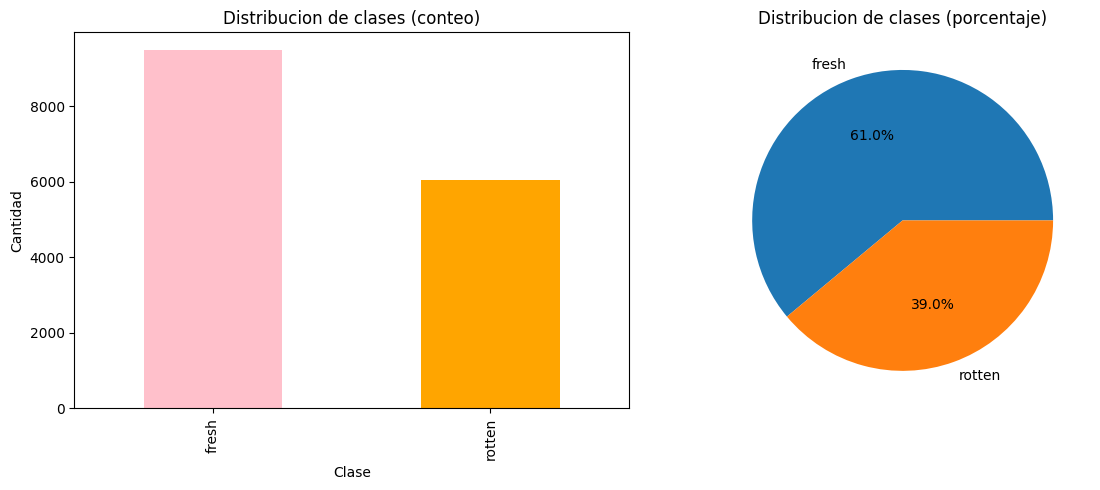

fresh
fresh     9482
rotten    6052
Name: count, dtype: int64


In [34]:
# TODO: Visualizar distribución de clases
# Instrucciones:
# 1. Cree una figura con 2 subplots (1 fila, 2 columnas)
# 2. En el primer subplot, use critics['fresh'].value_counts().plot(kind='bar')
# 3. En el segundo subplot, use .plot(kind='pie', autopct='%1.1f%%')
# 4. Agregue títulos y etiquetas
# 5. Imprima el conteo de clases

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
critics['fresh'].value_counts().plot(kind='bar', ax=axes[0], color=['pink', 'orange'])
axes[0].set_title('Distribucion de clases (conteo)')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad')

critics['fresh'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Distribucion de clases (porcentaje)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()
print(critics['fresh'].value_counts())


### Pregunta 2: Balance de Clases
¿Cuál es la clase mayoritaria en el dataset?

A) rotten (negativas)  
B) fresh (positivas)  
C) Están perfectamente balanceadas  
D) No se puede determinar  

**Su Respuesta:** B

       quote_length    word_count
count  15534.000000  15534.000000
mean     117.013261     19.447534
std       57.580916      9.792644
min        4.000000      1.000000
25%       72.000000     12.000000
50%      114.000000     19.000000
75%      158.000000     26.000000
max      256.000000     49.000000


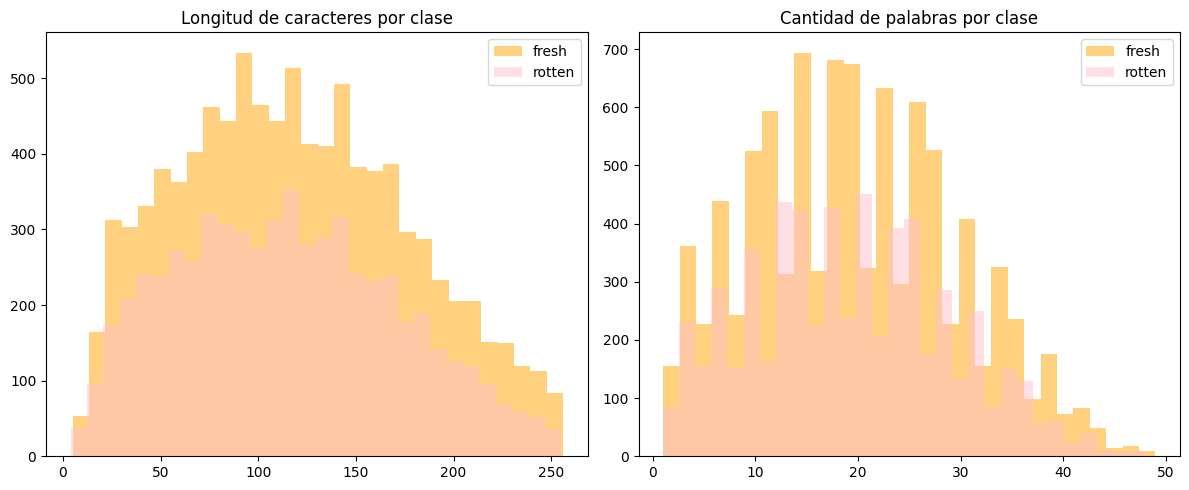

In [35]:
# TODO: Analizar longitud de las reseñas
# Instrucciones:
# 1. Cree una columna 'quote_length' con la longitud de cada quote: critics['quote'].apply(len)
# 2. Cree una columna 'word_count' con el número de palabras: critics['quote'].apply(lambda x: len(str(x).split()))
# 3. Imprima estadísticas descriptivas de estas columnas
# 4. Opcional: Cree histogramas comparando fresh vs rotten

critics['quote_length'] = critics['quote'].apply(len)
critics['word_count'] = critics['quote'].apply(lambda x: len(str(x).split()))

print(critics[['quote_length', 'word_count']].describe())
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for clase, color in zip(['fresh', 'rotten'], ['orange', 'pink']):
    axes[0].hist(critics[critics['fresh'] == clase]['quote_length'], bins=30, alpha=0.5, label=clase, color=color)
    axes[1].hist(critics[critics['fresh'] == clase]['word_count'], bins=30, alpha=0.5, label=clase, color=color)
axes[0].set_title('Longitud de caracteres por clase')
axes[0].legend()
axes[1].set_title('Cantidad de palabras por clase')
axes[1].legend()
plt.tight_layout()
plt.show()


In [8]:
# TODO: Mostrar ejemplos de reseñas
# Instrucciones:
# 1. Imprima 3 ejemplos de reseñas 'fresh' usando critics[critics['fresh']=='fresh']['quote'].head(3)
# 2. Imprima 3 ejemplos de reseñas 'rotten'

print('Ejemplos de resenas FRESH:')
print(critics[critics['fresh'] == 'fresh']['quote'].head(3))

print('\nEjemplos de resenas ROTTEN:')
print(critics[critics['fresh'] == 'rotten']['quote'].head(3))


Ejemplos de resenas FRESH:
1    So ingenious in concept, design and execution ...
2                    The year's most inventive comedy.
3    A winning animated feature that has something ...
Name: quote, dtype: object

Ejemplos de resenas ROTTEN:
30    A gloomy special-effects extravaganza filled w...
37                               Mediocre, regrettably.
40    The movie is too pat and practiced to really b...
Name: quote, dtype: object


## Parte 3: Preprocesamiento de Texto - Bag of Words

### Teoría:
El modelo **Bag of Words (BoW)** representa el texto como un vector de frecuencias de palabras, ignorando el orden. **CountVectorizer** de Scikit-Learn implementa este enfoque.

$$\text{Vector} = [\text{count}(w_1), \text{count}(w_2), ..., \text{count}(w_n)]$$

In [38]:
# TODO: Crear una función para preparar los datos
# Instrucciones:
# 1. Defina la función make_xy(data, vectorizer) que:
#    a. Aplique vectorizer.fit_transform(data['quote']) para obtener X
#    b. Convierta 'fresh' a binario: y = (data['fresh'] == 'fresh').astype(int).values
#    c. Retorne X, y

def make_xy(data, vectorizer):
    X = vectorizer.fit_transform(data['quote'])
    y = (data['fresh'] == 'fresh').astype(int).values
    return X, y


In [39]:
# TODO: Aplicar CountVectorizer
# Instrucciones:
# 1. Cree vectorizer = CountVectorizer(min_df=5)
# 2. Use make_xy() para obtener X, y
# 3. Imprima la forma de X y y
# 4. Imprima algunos ejemplos de palabras del vocabulario con vectorizer.get_feature_names_out()[:20]

vectorizer = CountVectorizer(min_df=5)
X, y = make_xy(critics, vectorizer)

print('Forma de X:', X.shape)
print('Forma de y:', y.shape)
print('Ejemplos de palabras del vocabulario:')
print(vectorizer.get_feature_names_out()[:20])


Forma de X: (15534, 6166)
Forma de y: (15534,)
Ejemplos de palabras del vocabulario:
['000' '007' '10' '100' '11' '12' '13' '13th' '15' '16' '17' '1930s'
 '1933' '1939' '1940s' '1950s' '1956' '1960s' '1961' '1963']


### Pregunta 3: Dimensiones del Vocabulario
¿Aproximadamente cuántas características (palabras únicas) tiene el vocabulario con min_df=5?

A) 500-1,000  
B) 1,000-5,000  
C) 5,000-10,000  
D) 10,000-20,000  

**Su Respuesta:** C

In [40]:
# TODO: Dividir en train y test
# Instrucciones:
# 1. Use train_test_split(X, y, test_size=0.3, random_state=42)
# 2. Asigne a X_train, X_test, y_train, y_test
# 3. Imprima los tamaños de cada conjunto
# 4. Imprima la distribución de clases en entrenamiento

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=19)
print('Tamano X_train:', X_train.shape)
print('Tamano X_test:', X_test.shape)
print('Distribucion de clases en entrenamiento:')
print(pd.Series(y_train).value_counts())

Tamano X_train: (10873, 6166)
Tamano X_test: (4661, 6166)
Distribucion de clases en entrenamiento:
1    6642
0    4231
Name: count, dtype: int64


## Parte 4: Naive Bayes Multinomial

### Teoría - Teorema de Bayes:
$$P(C|X) = \frac{P(X|C) \cdot P(C)}{P(X)}$$

**Naive Bayes** asume independencia condicional entre características:
$$P(X|C) = P(x_1|C) \cdot P(x_2|C) \cdot ... \cdot P(x_n|C)$$

**Multinomial Naive Bayes** es apropiado para conteos de palabras.

In [41]:
# TODO: Entrenar Multinomial Naive Bayes
# Instrucciones:
# 1. Cree el modelo: clf_nb = MultinomialNB()
# 2. Entrene con clf_nb.fit(X_train, y_train)
# 3. Prediga en train y test
# 4. Calcule y muestre las precisiones en train y test con accuracy_score()

clf_nb = MultinomialNB()
clf_nb.fit(X_train, y_train)

y_pred_train = clf_nb.predict(X_train)
y_pred_test = clf_nb.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print('Precision en entrenamiento:', acc_train)
print('Precision en prueba:', acc_test)

Precision en entrenamiento: 0.8697691529476685
Precision en prueba: 0.7689337052134735


### Pregunta 4: Precisión del Modelo Base
¿Cuál es la precisión aproximada del modelo Naive Bayes en el conjunto de prueba?

A) 60-70%  
B) 70-80%  
C) 80-90%  
D) 90-100%  

**Su Respuesta:** B

## Parte 5: Matriz de Confusión y Métricas

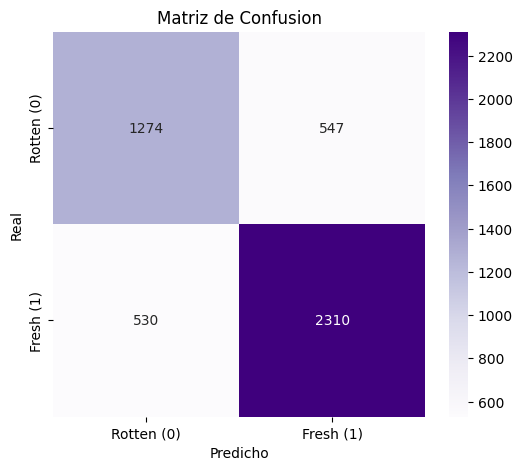

TN: 1274 | FP: 547 | FN: 530 | TP: 2310


In [43]:
# TODO: Calcular y visualizar la matriz de confusión
# Instrucciones:
# 1. Calcule cm = confusion_matrix(y_test, y_pred_test)
# 2. Visualice con sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# 3. Configure xticklabels y yticklabels como ['Rotten (0)', 'Fresh (1)']
# 4. Imprima TN, FP, FN, TP

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Rotten (0)', 'Fresh (1)'],
            yticklabels=['Rotten (0)', 'Fresh (1)'])
plt.title('Matriz de Confusion')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

tn, fp, fn, tp = cm.ravel()
print('TN:', tn, '| FP:', fp, '| FN:', fn, '| TP:', tp)


In [44]:
# TODO: Calcular métricas detalladas
# Instrucciones:
# 1. Calcule precision = precision_score(y_test, y_pred_test)
# 2. Calcule recall = recall_score(y_test, y_pred_test)
# 3. Calcule f1 = f1_score(y_test, y_pred_test)
# 4. Imprima las métricas
# 5. Use classification_report() para el reporte completo

precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)

print('Precision:', precision)
print('Recall:', recall)
print('F1-Score:', f1)
print('\nReporte de clasificacion completo:')
print(classification_report(y_test, y_pred_test, target_names=['Rotten', 'Fresh']))


Precision: 0.8085404270213511
Recall: 0.8133802816901409
F1-Score: 0.8109531332280148

Reporte de clasificacion completo:
              precision    recall  f1-score   support

      Rotten       0.71      0.70      0.70      1821
       Fresh       0.81      0.81      0.81      2840

    accuracy                           0.77      4661
   macro avg       0.76      0.76      0.76      4661
weighted avg       0.77      0.77      0.77      4661



### Pregunta 5: Interpretación de Métricas
Si el modelo tiene alto recall pero baja precisión para la clase 'Fresh', ¿qué significa?

A) El modelo detecta bien las reseñas positivas pero también clasifica muchas negativas como positivas  
B) El modelo no detecta las reseñas positivas  
C) El modelo es perfecto  
D) El modelo solo predice negativas  

**Su Respuesta:** A

## Parte 6: Efecto del Parámetro Alpha (Suavizado Laplaciano)

### Teoría:
El parámetro `alpha` es el **suavizado de Laplace** (additive smoothing). Evita probabilidades de cero para palabras no vistas:

$$P(w|C) = \frac{\text{count}(w,C) + \alpha}{\text{count}(C) + \alpha \cdot |V|}$$

- alpha=1.0: Suavizado estándar (default)
- alpha<1.0: Menos suavizado
- alpha>1.0: Más suavizado

In [45]:
# TODO: Experimentar con diferentes valores de alpha
# Instrucciones:
# 1. Defina alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
# 2. Para cada alpha:
#    a. Cree MultinomialNB(alpha=alpha)
#    b. Entrene y calcule precisiones train/test
#    c. Calcule precision y recall
# 3. Guarde resultados en un DataFrame e imprima

alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
resultados_alpha = []

for alpha in alphas:
    clf_alpha = MultinomialNB(alpha=alpha)
    clf_alpha.fit(X_train, y_train)

    pred_train = clf_alpha.predict(X_train)
    pred_test = clf_alpha.predict(X_test)

    train_acc = accuracy_score(y_train, pred_train)
    test_acc = accuracy_score(y_test, pred_test)
    prec = precision_score(y_test, pred_test)
    rec = recall_score(y_test, pred_test)

    resultados_alpha.append({
        'alpha': alpha,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'precision': prec,
        'recall': rec
    })

df_alphas = pd.DataFrame(resultados_alpha)
print(df_alphas)

    alpha  train_acc  test_acc  precision    recall
0   0.001   0.880898  0.752414   0.784990  0.817606
1   0.010   0.880530  0.756275   0.789402  0.818310
2   0.100   0.878690  0.762712   0.799378  0.815141
3   0.500   0.873724  0.764214   0.805760  0.807746
4   1.000   0.869769  0.768934   0.808540  0.813380
5   2.000   0.858273  0.772366   0.803066  0.829930
6   5.000   0.832705  0.758206   0.756207  0.890141
7  10.000   0.767681  0.709075   0.688804  0.953169


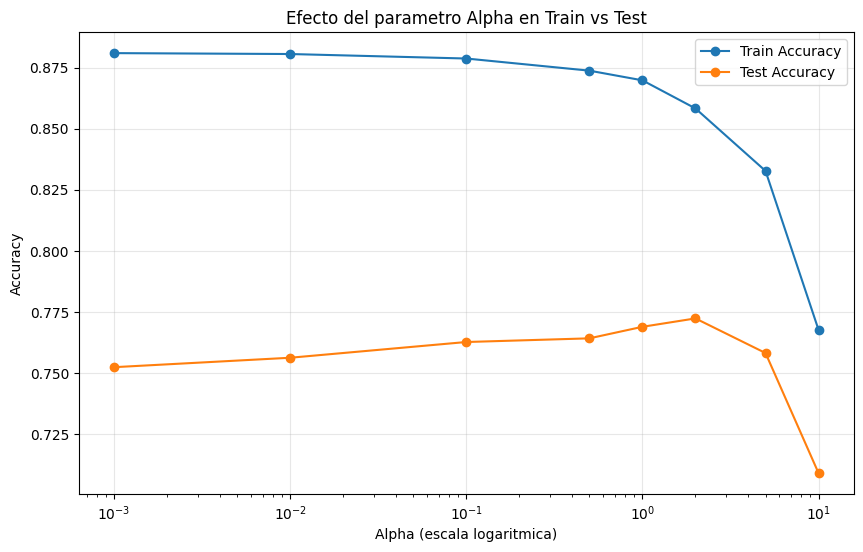

In [46]:
# TODO: Visualizar el efecto de alpha
# Instrucciones:
# 1. Grafique train_scores y test_scores vs alphas
# 2. Use plt.xscale('log') para escala logarítmica
# 3. Agregue leyenda, título y etiquetas

plt.figure(figsize=(10, 6))
plt.plot(df_alphas['alpha'], df_alphas['train_acc'], marker='o', label='Train Accuracy')
plt.plot(df_alphas['alpha'], df_alphas['test_acc'], marker='o', label='Test Accuracy')
plt.xscale('log')
plt.xlabel('Alpha (escala logaritmica)')
plt.ylabel('Accuracy')
plt.title('Efecto del parametro Alpha en Train vs Test')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

B### Pregunta 6: Efecto de Alpha
¿Qué ocurre cuando alpha es muy pequeño (ej: 0.001)?

A) El modelo generaliza mejor  
B) El modelo tiende a sobreajustar (train acc >> test acc)  
C) El modelo no aprende nada  
D) No hay efecto significativo  

**Su Respuesta:** B

## Parte 7: N-gramas

### Teoría:
Los **n-gramas** capturan secuencias de n palabras consecutivas:
- Unigrama (1-gram): palabras individuales
- Bigrama (2-gram): pares de palabras
- Trigrama (3-gram): tríos de palabras

Ejemplo: "I love this movie"
- Unigramas: ["I", "love", "this", "movie"]
- Bigramas: ["I love", "love this", "this movie"]

In [47]:
# TODO: Experimentar con diferentes n-gramas
# Instrucciones:
# 1. Defina ngram_configs = [(1,1), (1,2), (2,2), (1,3), (2,3)]
# 2. Para cada configuración:
#    a. Cree CountVectorizer(ngram_range=ngram, min_df=5)
#    b. Use make_xy() para crear X, y
#    c. Divida en train/test
#    d. Entrene MultinomialNB y calcule precisiones
# 3. Imprima los resultados comparativos

ngram_configs = [(1,1), (1,2), (2,2), (1,3), (2,3)]
resultados_ngram = []

for ngram in ngram_configs:
    vect_ngram = CountVectorizer(ngram_range=ngram, min_df=5)
    X_ngram, y_ngram = make_xy(critics, vect_ngram)

    X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
        X_ngram, y_ngram, test_size=0.3, random_state=19)

    clf_ngram = MultinomialNB()
    clf_ngram.fit(X_train_n, y_train_n)

    train_acc = accuracy_score(y_train_n, clf_ngram.predict(X_train_n))
    test_acc = accuracy_score(y_test_n, clf_ngram.predict(X_test_n))

    resultados_ngram.append({
        'ngram_range': ngram,
        'n_features': X_ngram.shape[1],
        'train_acc': train_acc,
        'test_acc': test_acc
    })

df_ngrams = pd.DataFrame(resultados_ngram)
print(df_ngrams)

  ngram_range  n_features  train_acc  test_acc
0      (1, 1)        6166   0.869769  0.768934
1      (1, 2)       13054   0.894601  0.767432
2      (2, 2)        6888   0.826359  0.681613
3      (1, 3)       14727   0.894509  0.764857
4      (2, 3)        8561   0.824152  0.680755


B### Pregunta 7: N-gramas
¿Qué ocurre al usar solo bigramas (2,2) en comparación con unigramas (1,1)?

A) Siempre mejora la precisión  
B) Aumenta mucho el número de características y puede sobreajustar  
C) Reduce el número de características  
D) No tiene ningún efecto  

**Su Respuesta:** B

## Parte 8: TF-IDF

### Teoría:
**TF-IDF** (Term Frequency - Inverse Document Frequency) pondera las palabras por su importancia:

$$\text{TF-IDF}(t,d) = \text{TF}(t,d) \times \text{IDF}(t)$$

Donde:
- TF(t,d): Frecuencia del término t en el documento d
- IDF(t): log(N / df(t)) - penaliza palabras muy comunes

In [48]:
# TODO: Aplicar TF-IDF
# Instrucciones:
# 1. Cree tfidf_vectorizer = TfidfVectorizer(min_df=5, stop_words='english')
# 2. Use make_xy() para crear X_tfidf, y_tfidf
# 3. Divida en train/test
# 4. Entrene MultinomialNB
# 5. Calcule y muestre precisiones train/test

tfidf_vectorizer = TfidfVectorizer(min_df=5, stop_words='english')
X_tfidf, y_tfidf = make_xy(critics, tfidf_vectorizer)

X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf, y_tfidf, test_size=0.3, random_state=19)

clf_tfidf = MultinomialNB()
clf_tfidf.fit(X_train_tfidf, y_train_tfidf)

train_acc_tfidf = accuracy_score(y_train_tfidf, clf_tfidf.predict(X_train_tfidf))
test_acc_tfidf = accuracy_score(y_test_tfidf, clf_tfidf.predict(X_test_tfidf))

print('Precision en entrenamiento (TF-IDF):', train_acc_tfidf)
print('Precision en prueba (TF-IDF):', test_acc_tfidf)

Precision en entrenamiento (TF-IDF): 0.8444771452221098
Precision en prueba (TF-IDF): 0.7534863763140957


In [49]:
# TODO: Imprimir reporte de clasificación con TF-IDF
# Instrucciones:
# 1. Prediga con el modelo TF-IDF
# 2. Use classification_report() para el reporte

y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)
print(classification_report(y_test_tfidf, y_pred_tfidf, target_names=['Rotten', 'Fresh']))


              precision    recall  f1-score   support

      Rotten       0.80      0.49      0.61      1821
       Fresh       0.74      0.92      0.82      2840

    accuracy                           0.75      4661
   macro avg       0.77      0.71      0.71      4661
weighted avg       0.76      0.75      0.74      4661



### Pregunta 8: TF-IDF vs CountVectorizer
¿Cuál es una ventaja de TF-IDF sobre CountVectorizer simple?

A) Siempre da mejor precisión  
B) Penaliza palabras muy comunes y reduce el sobreajuste  
C) Usa menos memoria  
D) Es más rápido de calcular  

**Su Respuesta:** B

## Parte 9: Interpretación del Modelo

In [50]:
# TODO: Identificar las palabras más predictivas
# Instrucciones:
# 1. Obtenga los nombres de características: feature_names = np.array(vectorizer.get_feature_names_out())
# 2. Obtenga log probabilidades: clf_nb.feature_log_prob_[1] (Fresh) y clf_nb.feature_log_prob_[0] (Rotten)
# 3. Calcule la diferencia: log_ratio = log_prob_fresh - log_prob_rotten
# 4. Use argsort() para encontrar las 15 palabras más positivas y negativas
# 5. Imprima las palabras con sus log ratios

feature_names = np.array(vectorizer.get_feature_names_out())
log_prob_fresh = clf_nb.feature_log_prob_[1]
log_prob_rotten = clf_nb.feature_log_prob_[0]
log_ratio = log_prob_fresh - log_prob_rotten

indices_ordenados = np.argsort(log_ratio)
palabras_negativas = feature_names[indices_ordenados[:15]]
ratios_negativos = log_ratio[indices_ordenados[:15]]
palabras_positivas = feature_names[indices_ordenados[-15:]]
ratios_positivos = log_ratio[indices_ordenados[-15:]]

print('Palabras mas asociadas a FRESH (positivas):')
for palabra, ratio in zip(palabras_positivas[::-1], ratios_positivos[::-1]):
    print(f'{palabra}: {ratio:.4f}')

print('\nPalabras mas asociadas a ROTTEN (negativas):')
for palabra, ratio in zip(palabras_negativas, ratios_negativos):
    print(f'{palabra}: {ratio:.4f}')

Palabras mas asociadas a FRESH (positivas):
delight: 3.0797
superb: 3.0499
rousing: 2.6444
captures: 2.6444
energetic: 2.5979
outstanding: 2.5491
myth: 2.4978
expertly: 2.4437
extraordinary: 2.4156
childhood: 2.3866
richly: 2.3866
witty: 2.3466
ingenious: 2.3259
tense: 2.3259
kubrick: 2.2942

Palabras mas asociadas a ROTTEN (negativas):
lame: -3.7047
pointless: -3.4912
unfortunately: -3.3088
uninspired: -3.1547
bland: -3.1208
tiresome: -3.0857
tepid: -3.0857
forgettable: -2.9315
overwrought: -2.9315
ok: -2.9315
unsatisfying: -2.8445
trailer: -2.8445
disappointment: -2.7980
besson: -2.7492
sluggish: -2.7492


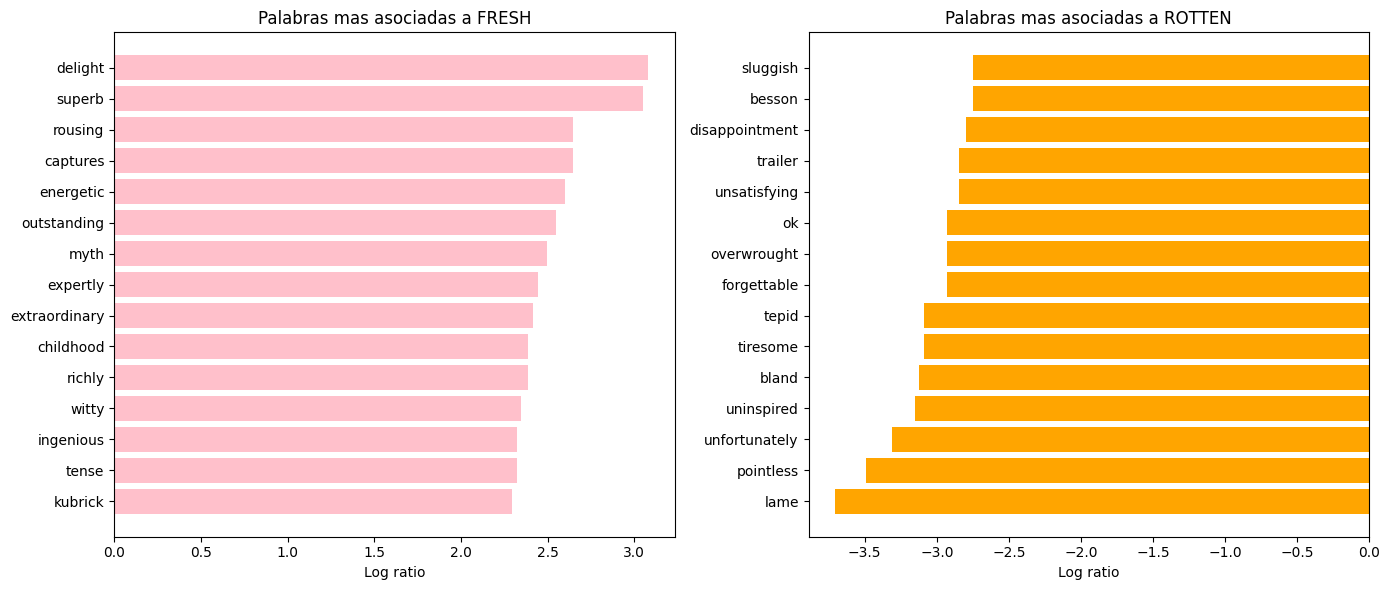

In [51]:
# TODO: Visualizar las palabras más predictivas
# Instrucciones:
# 1. Cree una figura con 2 subplots (1 fila, 2 columnas)
# 2. En el primer subplot, grafique las palabras más positivas con barh()
# 3. En el segundo subplot, grafique las palabras más negativas
# 4. Agregue títulos y etiquetas

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(palabras_positivas, ratios_positivos, color='pink')
axes[0].set_title('Palabras mas asociadas a FRESH')
axes[0].set_xlabel('Log ratio')

axes[1].barh(palabras_negativas, ratios_negativos, color='orange')
axes[1].set_title('Palabras mas asociadas a ROTTEN')
axes[1].set_xlabel('Log ratio')

plt.tight_layout()
plt.show()

### Pregunta 9: Interpretabilidad
¿Qué tipo de palabras esperaría encontrar asociadas a reseñas negativas?

A) Palabras como "excellent", "amazing", "brilliant"  
B) Palabras como "boring", "bad", "disappointing"  
C) Palabras neutrales como "the", "and", "is"  
D) Nombres de actores  

**Su Respuesta:** B

## Parte 10: Predicción con Nuevas Reseñas

In [52]:
# TODO: Probar el modelo con nuevas reseñas
# Instrucciones:
# 1. Defina una lista de nuevas reseñas de ejemplo
# 2. Transforme con vectorizer.transform(new_reviews)
# 3. Prediga con clf_nb.predict()
# 4. Obtenga probabilidades con clf_nb.predict_proba()
# 5. Imprima cada reseña con su predicción y probabilidades

new_reviews = [
    "This movie is absolutely amazing! Best film of the year!",
    "Terrible waste of time. Boring and predictable.",
    "A decent film with good performances but weak plot.",
    "Masterpiece! Incredible acting and stunning visuals.",
    "I've seen better. Nothing special about this one."
]

X_new = vectorizer.transform(new_reviews)
predicciones = clf_nb.predict(X_new)
probabilidades = clf_nb.predict_proba(X_new)

for resena, pred, prob in zip(new_reviews, predicciones, probabilidades):
    etiqueta = 'Fresh' if pred == 1 else 'Rotten'
    print(f'Resena: {resena}')
    print(f'Prediccion: {etiqueta} | P(Rotten)={prob[0]:.4f}, P(Fresh)={prob[1]:.4f}\n')

Resena: This movie is absolutely amazing! Best film of the year!
Prediccion: Fresh | P(Rotten)=0.0376, P(Fresh)=0.9624

Resena: Terrible waste of time. Boring and predictable.
Prediccion: Rotten | P(Rotten)=0.9791, P(Fresh)=0.0209

Resena: A decent film with good performances but weak plot.
Prediccion: Fresh | P(Rotten)=0.4940, P(Fresh)=0.5060

Resena: Masterpiece! Incredible acting and stunning visuals.
Prediccion: Fresh | P(Rotten)=0.0070, P(Fresh)=0.9930

Resena: I've seen better. Nothing special about this one.
Prediccion: Rotten | P(Rotten)=0.6882, P(Fresh)=0.3118



### Pregunta 10: Predicciones
¿Qué método se usa para obtener las probabilidades de cada clase?

A) predict()  
B) predict_proba()  
C) score()  
D) fit()  

**Su Respuesta:** B

## Parte 11: Comparación de Modelos

In [53]:
# TODO: Comparar Multinomial vs Bernoulli Naive Bayes
# Instrucciones:
# 1. Cree y entrene BernoulliNB() con los mismos datos
# 2. Calcule precisiones train/test
# 3. Cree un DataFrame comparando:
#    - Multinomial NB
#    - Bernoulli NB
#    - Multinomial + TF-IDF
# 4. Imprima la tabla comparativa

clf_bernoulli = BernoulliNB()
clf_bernoulli.fit(X_train, y_train)

train_acc_bnb = accuracy_score(y_train, clf_bernoulli.predict(X_train))
test_acc_bnb = accuracy_score(y_test, clf_bernoulli.predict(X_test))

comparacion = pd.DataFrame({
    'Modelo': ['Multinomial NB', 'Bernoulli NB', 'Multinomial + TF-IDF'],
    'Train Accuracy': [acc_train, train_acc_bnb, train_acc_tfidf],
    'Test Accuracy': [acc_test, test_acc_bnb, test_acc_tfidf]
})

print(comparacion)

                 Modelo  Train Accuracy  Test Accuracy
0        Multinomial NB        0.869769       0.768934
1          Bernoulli NB        0.865998       0.770865
2  Multinomial + TF-IDF        0.844477       0.753486


### Pregunta 11: Multinomial vs Bernoulli
¿Cuál es la diferencia principal entre Multinomial y Bernoulli Naive Bayes?

A) No hay diferencia  
B) Multinomial usa conteos de palabras, Bernoulli usa presencia/ausencia binaria  
C) Bernoulli es siempre mejor  
D) Multinomial solo funciona con TF-IDF  

**Su Respuesta:** B

### Pregunta 12: Suposición de Naive Bayes
¿Cuál es la suposición principal del algoritmo Naive Bayes?

A) Las características tienen distribución normal  
B) Las características son independientes dada la clase  
C) Los datos deben estar normalizados  
D) Debe haber balance de clases  

**Su Respuesta:** B

### Pregunta 13: Ventajas de Naive Bayes
¿Cuál es una ventaja de Naive Bayes para clasificación de texto?

A) Siempre da la mejor precisión  
B) Es rápido de entrenar y funciona bien con alta dimensionalidad  
C) No requiere preprocesamiento  
D) Captura relaciones complejas entre palabras  

**Su Respuesta:** B

### Pregunta 14: Stop Words
¿Qué son las "stop words" en procesamiento de texto?

A) Palabras con errores ortográficos  
B) Palabras muy comunes que aportan poca información (the, is, and)  
C) Palabras negativas  
D) Palabras técnicas  

**Su Respuesta:** B

### Pregunta 15: min_df en CountVectorizer
¿Qué hace el parámetro min_df=5 en CountVectorizer?

A) Limita a 5 palabras por documento  
B) Ignora palabras que aparecen en menos de 5 documentos  
C) Usa solo las 5 palabras más frecuentes  
D) Divide los datos en 5 partes  

**Su Respuesta:** B

## ¡Excelente Trabajo!

Responda las preguntas basadas en sus ejecuciones. Entregue el notebook completado con todas las celdas ejecutadas.